In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow

In [2]:
from pathlib import Path

DATA_PATH = Path("./Data")
RAW_DATA_PATH = DATA_PATH / "raw" / "Fraud_Data.csv"

In [3]:
mlflow.set_tracking_uri("http://localhost:5000")

In [4]:
mlflow.set_experiment("Fraud Detection")

<Experiment: artifact_location='file:C:/Users/trixr/Desktop/FraudDetection/mlflow-data/artifacts/1', creation_time=1781179797941, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1781179797941, lifecycle_stage='active', name='Fraud Detection', tags={}, trace_location=None, workspace='default'>

In [5]:
mlflow.start_run(run_name="EDA_Fraud")

<ActiveRun: >

# Load Data
---

In [6]:
df = pd.read_csv(RAW_DATA_PATH)

# Basic Analysis
---

In [7]:
df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  object 
 2   purchase_time   151112 non-null  object 
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  object 
 5   source          151112 non-null  object 
 6   browser         151112 non-null  object 
 7   sex             151112 non-null  object 
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 12.7+ MB


## Types

In [33]:
df["signup_time"] = pd.to_datetime(
    df["signup_time"],
    format="%Y-%m-%d %H:%M:%S",
    errors="coerce"
)

df["purchase_time"] = pd.to_datetime(
    df["purchase_time"],
    format="%Y-%m-%d %H:%M:%S",
    errors="coerce"
)

In [34]:
import ipaddress

df["ip_address"] = df["ip_address"].astype("int64").apply(
    lambda x: str(ipaddress.IPv4Address(x))
)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   user_id         151112 non-null  int64         
 1   signup_time     151112 non-null  datetime64[ns]
 2   purchase_time   151112 non-null  datetime64[ns]
 3   purchase_value  151112 non-null  int64         
 4   device_id       151112 non-null  object        
 5   source          151112 non-null  object        
 6   browser         151112 non-null  object        
 7   sex             151112 non-null  object        
 8   age             151112 non-null  int64         
 9   ip_address      151112 non-null  object        
 10  class           151112 non-null  int64         
dtypes: datetime64[ns](2), int64(4), object(5)
memory usage: 12.7+ MB


In [12]:
df[["purchase_value","age"]].describe()

,purchase_value,age
count,151112.000000,151112.000000
mean,36.935372,33.140704
std,18.322762,8.617733
min,9.000000,18.000000
25%,22.000000,27.000000
50%,35.000000,33.000000
75%,49.000000,39.000000
max,154.000000,76.000000


In [13]:
for col in ["source", "browser", "sex", "class"]:
    print(f"{col} : {df[col].unique()}")

source : ['SEO' 'Ads' 'Direct']
browser : ['Chrome' 'Opera' 'Safari' 'IE' 'FireFox']
sex : ['M' 'F']
class : [0 1]


## Nulls

In [14]:
df.isnull().sum()

user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

## Duplicates

In [15]:
df.duplicated(
    subset=["user_id", "purchase_time"]
    ).sum()

np.int64(0)

In [38]:
from collections import defaultdict

# Build a string report
report_lines = []
report_lines.append("DataFrame Summary")
report_lines.append("=" * 50)
report_lines.append(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
report_lines.append("\nColumns and Data Types:")

col_dict = defaultdict(list)
for col in df.columns:
    example = df[col].iloc[0] if len(df) > 0 else "No data"
    col_dict[col].append(f"data type: {df[col].dtype}, example: {example}")

# Add notes for specific columns (optional)
col_dict["signup_time"].append("\n→ DateTime conversion needed")
col_dict["purchase_time"].append("\n→ DateTime conversion needed")
col_dict["ip_address"].append("\n→ IP address conversion needed")

# Format the dict nicely
for col, notes in col_dict.items():
    report_lines.append(f"{col}: {', '.join(notes)}")

# Create the final report string
report_str = "\n".join(report_lines)

# Log to MLflow (within an active run)
mlflow.log_text(report_str, "eda/dataframe_summary.txt")

# Univariate Analysis
---

In [39]:
cols = ["user_id", "signup_time", "purchase_time",
        "device_id", "ip_address"]

categorical_cols = ["source", "browser", "sex", "class"]

numerical_cols = ["purchase_value", "age"]

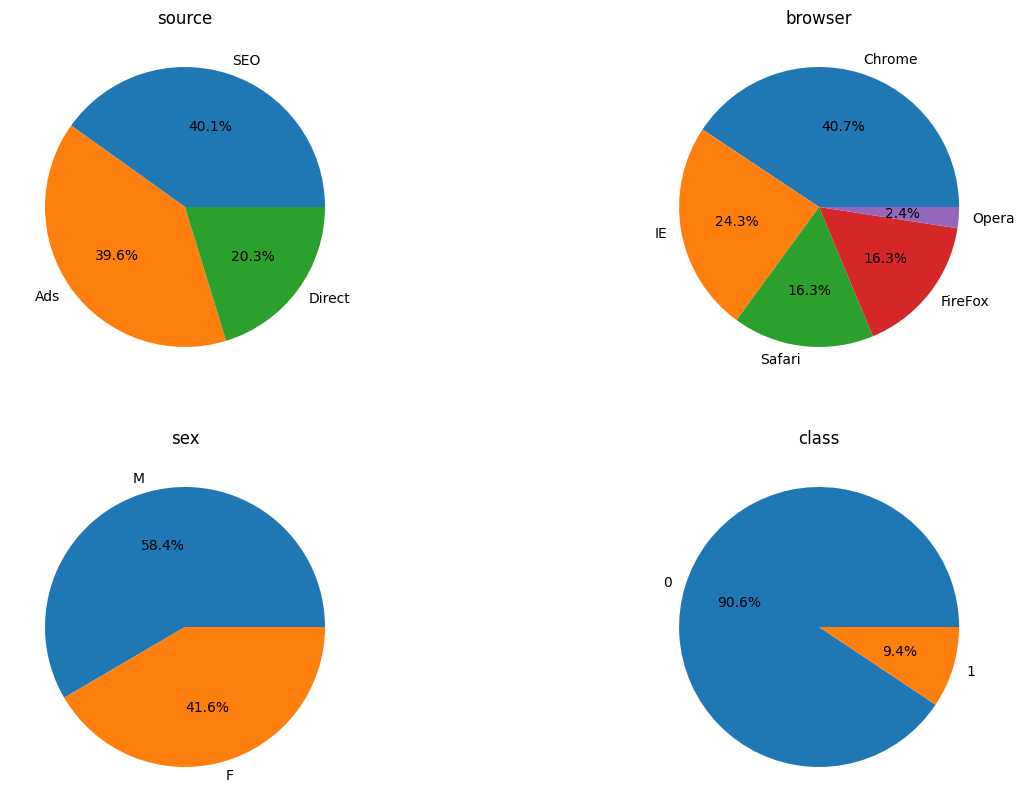

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(
        kind="pie",
        ax=axes[i],
        autopct="%1.1f%%"
    )
    axes[i].set_title(col)
    axes[i].set_ylabel("")

mlflow.log_figure(fig, "eda/univariate/categorical_pie_charts.png")

plt.show()

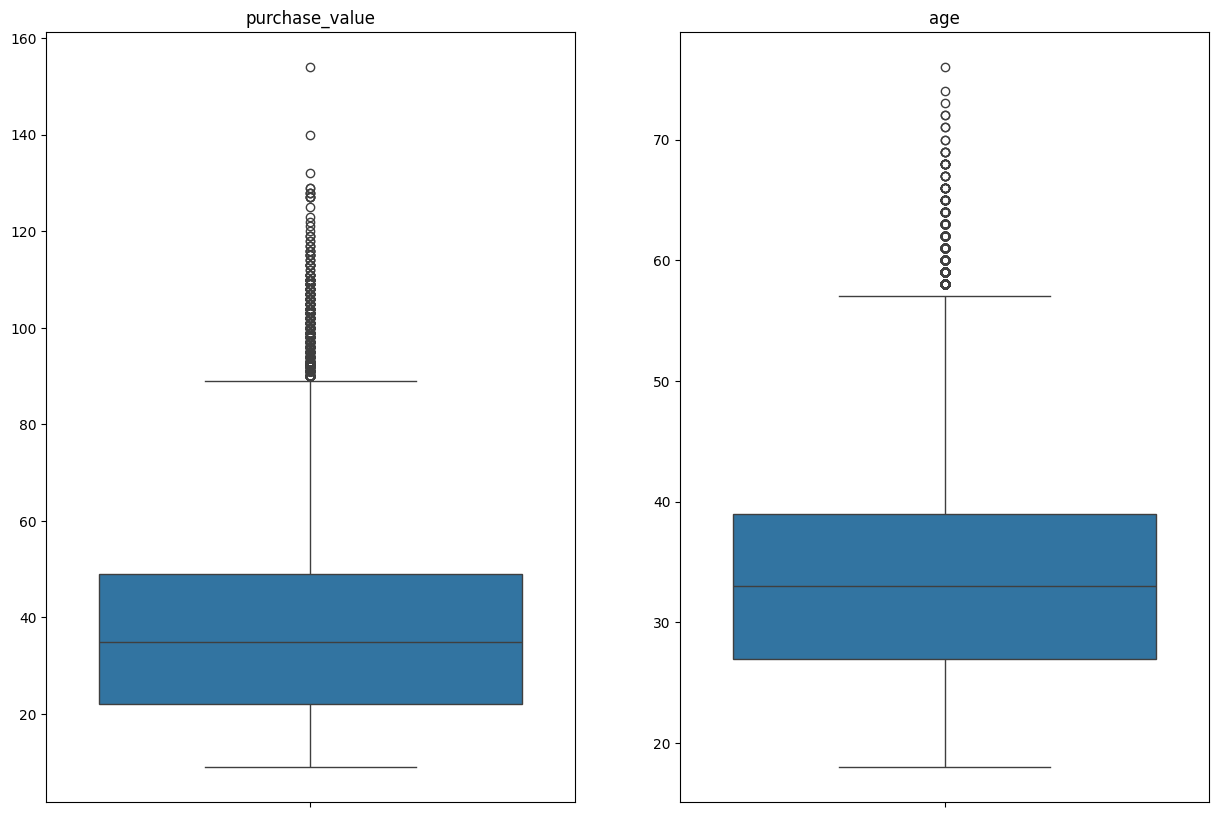

In [41]:
fig, axes = plt.subplots(1,2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(df[col], ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel("")

mlflow.log_figure(fig, "eda/univariate/numerical_box_plot.png")

plt.show()

# Bivariate Analysis
---

### UserIDs, IPs and DeviceIDs

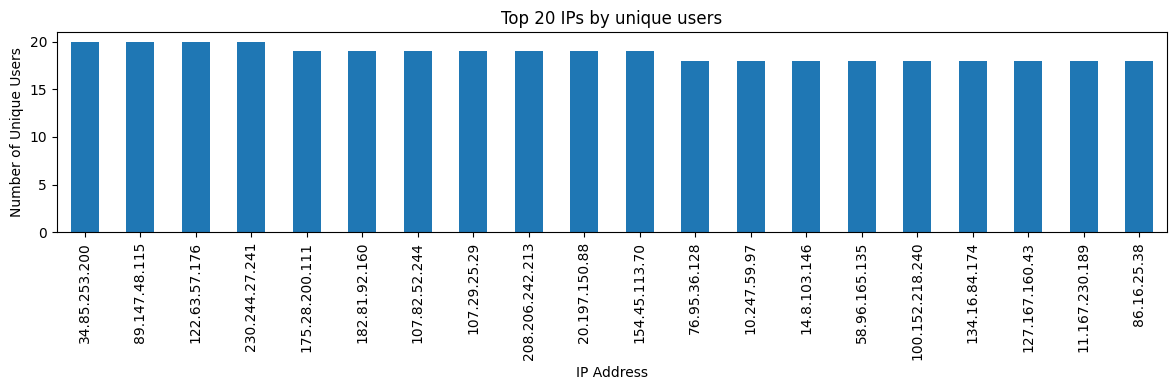

In [42]:
# Create the plot
top_ip = df.groupby("ip_address")["user_id"].nunique().sort_values(ascending=False).head(20)
ax = top_ip.plot(kind="bar", figsize=(12, 4), title="Top 20 IPs by unique users")
ax.set_xlabel("IP Address")
ax.set_ylabel("Number of Unique Users")
plt.tight_layout()

# Get the figure from the Axes object
fig = ax.get_figure()
mlflow.log_figure(fig, "eda/bivariate/top_ips_barplot.png")

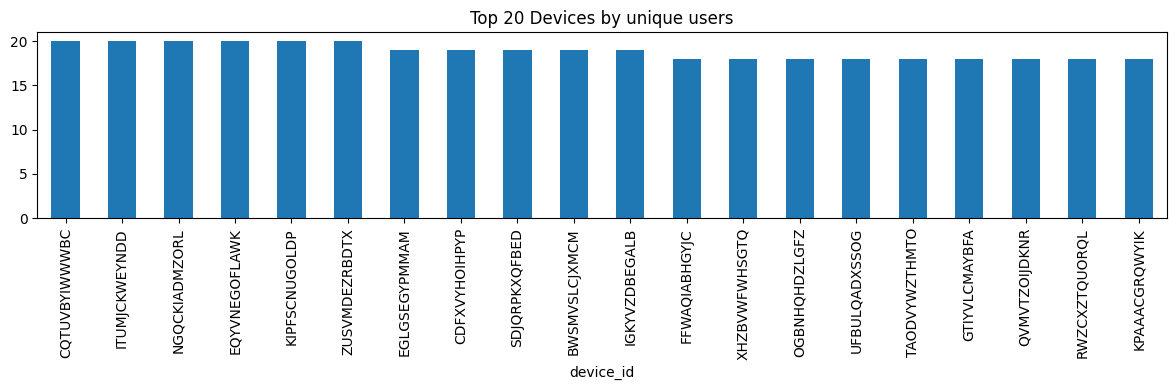

In [43]:
top_dids = df.groupby("device_id")["user_id"].nunique().sort_values(ascending=False).head(20)
ax = top_dids.plot(kind="bar", figsize=(12, 4), title="Top 20 Devices by unique users")
plt.tight_layout()
# Get the figure from the Axes object
fig = ax.get_figure()
mlflow.log_figure(fig, "eda/bivariate/top_devices_barplot.png")

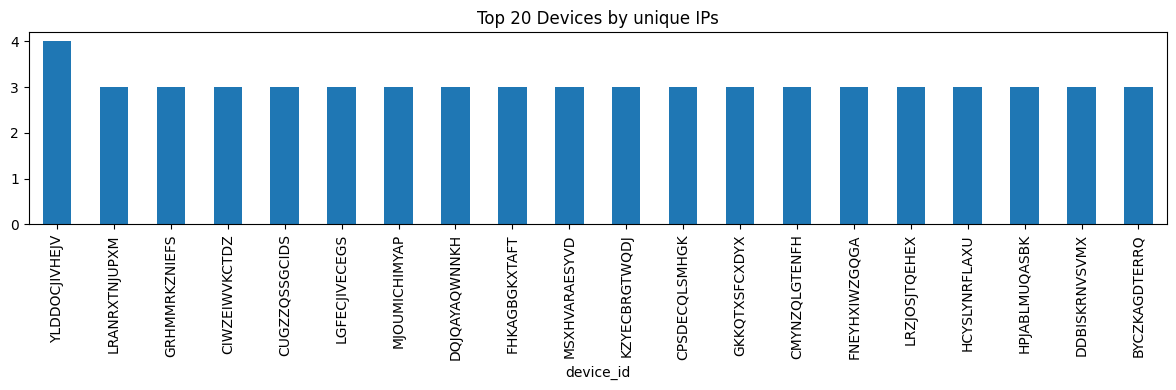

In [44]:
ax = df.groupby("device_id")["ip_address"] \
    .nunique().sort_values(ascending=False) \
    .head(20).plot(kind="bar", figsize=(12, 4), title="Top 20 Devices by unique IPs")

plt.tight_layout()
# Get the figure from the Axes object
fig = ax.get_figure()
mlflow.log_figure(fig, "eda/bivariate/top_devices_by_unique_ips_barplot.png")

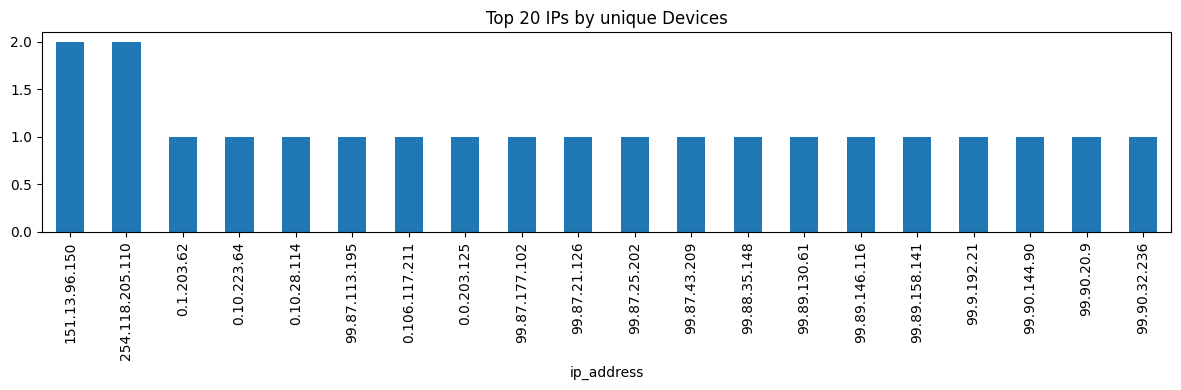

In [45]:
ax = df.groupby("ip_address")["device_id"] \
    .nunique().sort_values(ascending=False) \
    .head(20).plot(kind="bar", figsize=(12, 4), title="Top 20 IPs by unique Devices")

plt.tight_layout()
# Get the figure from the Axes object
fig = ax.get_figure()
mlflow.log_figure(fig, "eda/bivariate/top_ips_by_unique_devices_barplot.png")

##


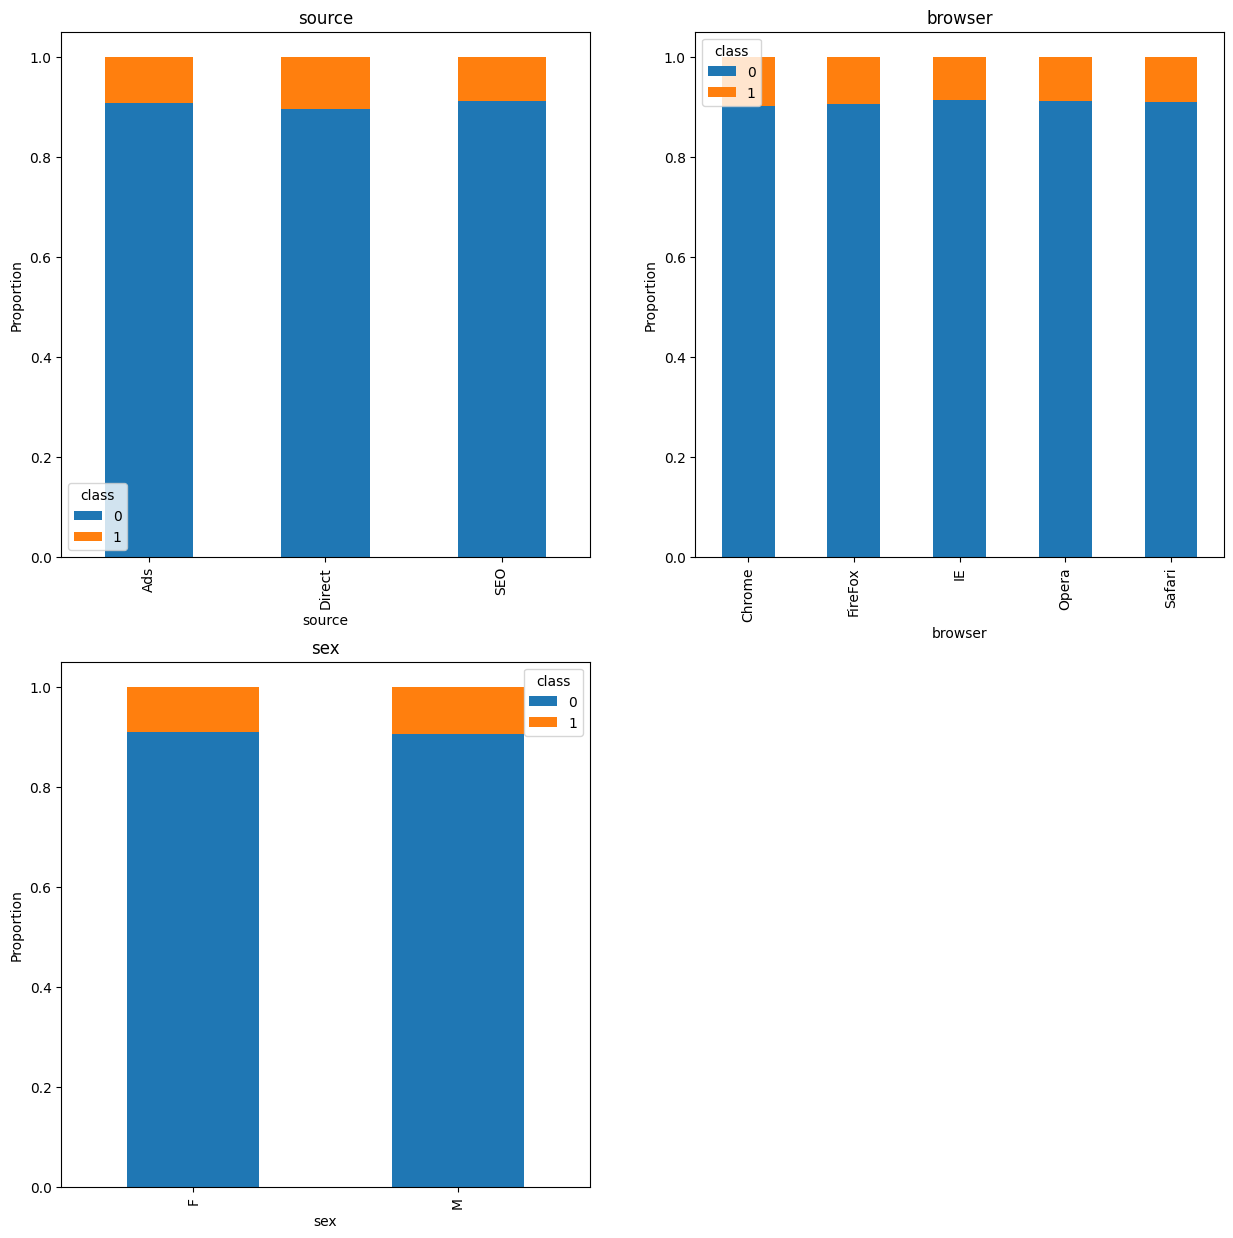

In [46]:
fig, axes = plt.subplots(2, 2, figsize=(15, 15))
axes = axes.flatten()
for i, col in enumerate(categorical_cols[:-1]):
    crosstab = pd.crosstab(df[col], df["class"], normalize="index")
    crosstab.plot(kind="bar", stacked=True, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_ylabel("Proportion")

fig.delaxes(axes[3])
mlflow.log_figure(fig, "eda/bivariate/categorical_bar_charts.png")
plt.show()

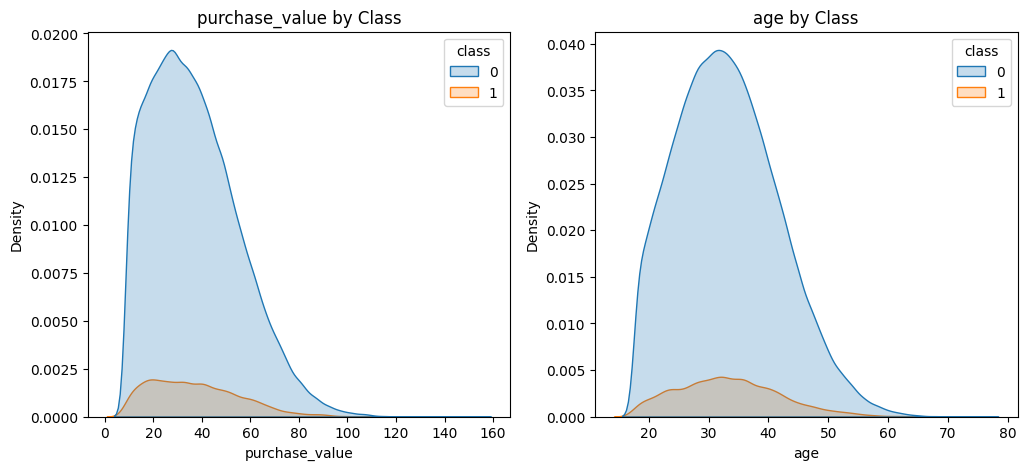

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.kdeplot(data=df, x=col, hue="class", fill=True, ax=axes[i], common_norm=True)
    axes[i].set_title(f"{col} by Class")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Density")
    
mlflow.log_figure(fig, "eda/bivariate/numerical_kde_chartswithcomonnorm.png")
plt.show()

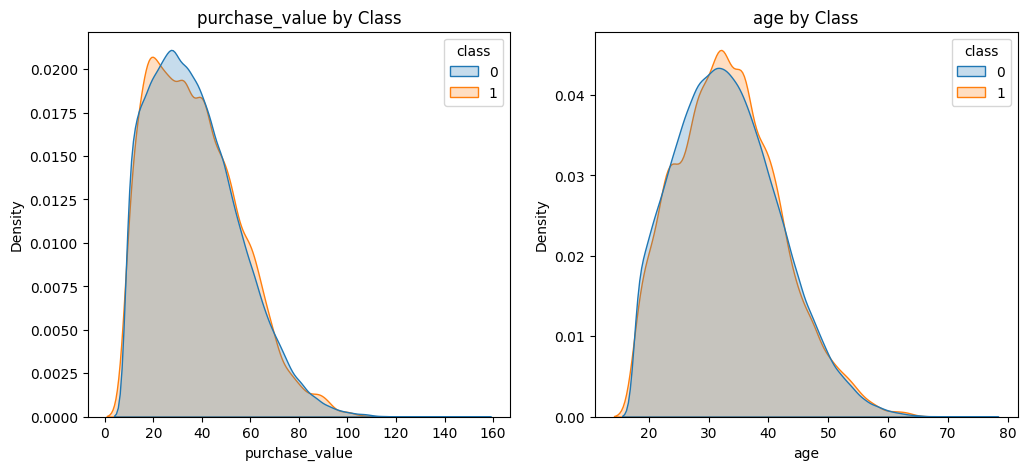

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.kdeplot(data=df, x=col, hue="class", fill=True, ax=axes[i], common_norm=False)
    axes[i].set_title(f"{col} by Class")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Density")

mlflow.log_figure(fig, "eda/bivariate/numerical_kde_chartswithout_comonnorm.png")
plt.show()

# Multivariate Analysis
---

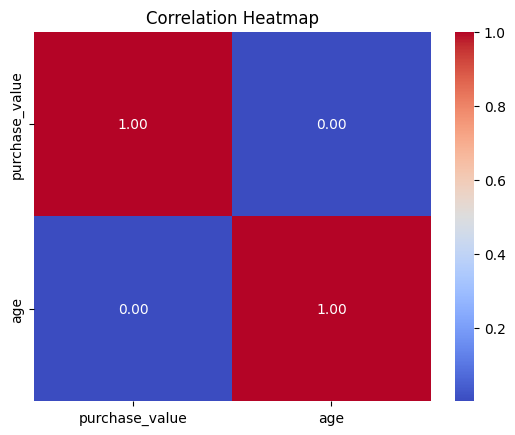

In [49]:
# Compute correlation matrix
corr_matrix = df[numerical_cols].corr(method="pearson")

# Plot heatmap
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")


# Get the current figure
fig = plt.gcf()  # "get current figure"
mlflow.log_figure(fig, "eda/multivariate/correlation.png")

plt.title("Correlation Heatmap")
plt.show()

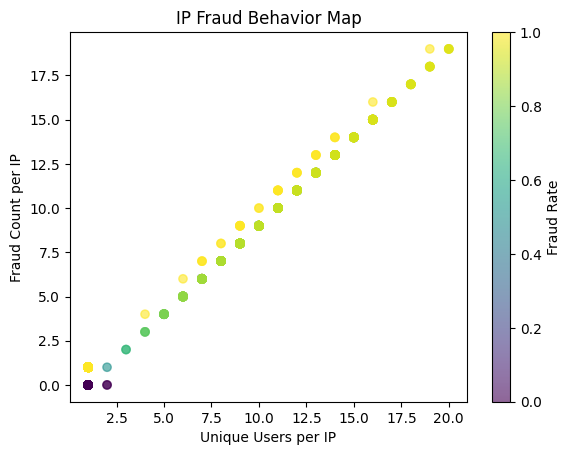

In [50]:
ip_stats = df.groupby("ip_address").agg(
    unique_users=("user_id", "nunique"),
    fraud_count=("class", "sum"),
    total_events=("class", "count")
).reset_index()
ip_stats["fraud_rate"] = ip_stats["fraud_count"] / ip_stats["total_events"]

plt.scatter(
    ip_stats["unique_users"],
    ip_stats["fraud_count"],
    c=ip_stats["fraud_rate"],
    alpha=0.6
)

plt.colorbar(label="Fraud Rate")
plt.xlabel("Unique Users per IP")
plt.ylabel("Fraud Count per IP")
plt.title("IP Fraud Behavior Map")

fig = plt.gcf()  # "get current figure"
mlflow.log_figure(fig, "eda/multivariate/fraudrate_fraudcount_uniqueusers.png")

plt.show()

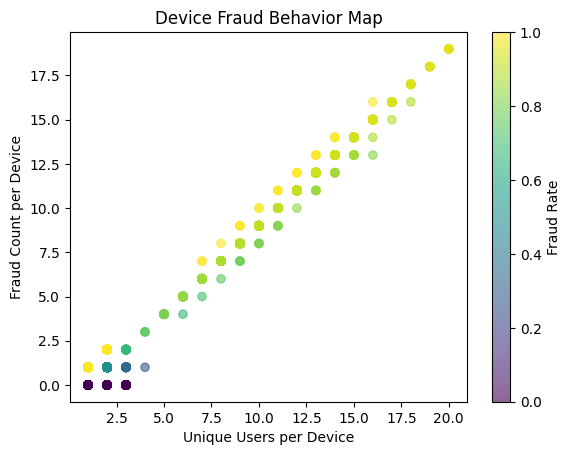

In [51]:
device_stats = df.groupby("device_id").agg(
    unique_users=("user_id", "nunique"),
    fraud_count=("class", "sum"),
    total_events=("class", "count")
).reset_index()
device_stats["fraud_rate"] = device_stats["fraud_count"] / device_stats["total_events"]

plt.scatter(
    device_stats["unique_users"],
    device_stats["fraud_count"],
    c=device_stats["fraud_rate"],
    alpha=0.6
)

plt.colorbar(label="Fraud Rate")
plt.xlabel("Unique Users per Device")
plt.ylabel("Fraud Count per Device")
plt.title("Device Fraud Behavior Map")
fig = plt.gcf()  # "get current figure"
mlflow.log_figure(fig, "eda/multivariate/uniqueusers_fraudcount_uniqueusers.png")
plt.show()

In [16]:
mlflow.end_run()

🏃 View run EDA_Fraud at: http://localhost:5000/#/experiments/1/runs/15313859fef948e186ac353eabcfef14
🧪 View experiment at: http://localhost:5000/#/experiments/1
